In [1]:
import numpy as np
from utils.data_utils import ImageNetSubset, WeatherImageNetSubset
from utils.fl_utils import init_clients

In [2]:
#Load 
orig_emb = np.load("weather_augmentations/embeddings_original.npy")
aug_emb = np.load("weather_augmentations/embeddings_augmented.npy")
class_ids = np.load("weather_augmentations/class_ids.npy")
weather_labels = np.load("weather_augmentations/weather_labels.npy", allow_pickle=True)

In [3]:
orig_dataset = ImageNetSubset(
    root="data/imnet_subset",
    split="train",
    transform=None  # no need for preprocess, just need the mappings
)

class_names = orig_dataset.classes

In [4]:
#Overall cosine similarity

cosine_sims = (orig_emb * aug_emb).sum(axis=1)  # (N,) — already L2 normalized

print(f"Overall cosine similarity:")
print(f"  mean : {cosine_sims.mean():.4f}")
print(f"  std  : {cosine_sims.std():.4f}")
print(f"  min  : {cosine_sims.min():.4f}")
print(f"  max  : {cosine_sims.max():.4f}")

Overall cosine similarity:
  mean : 0.7831
  std  : 0.1002
  min  : 0.1654
  max  : 0.9865


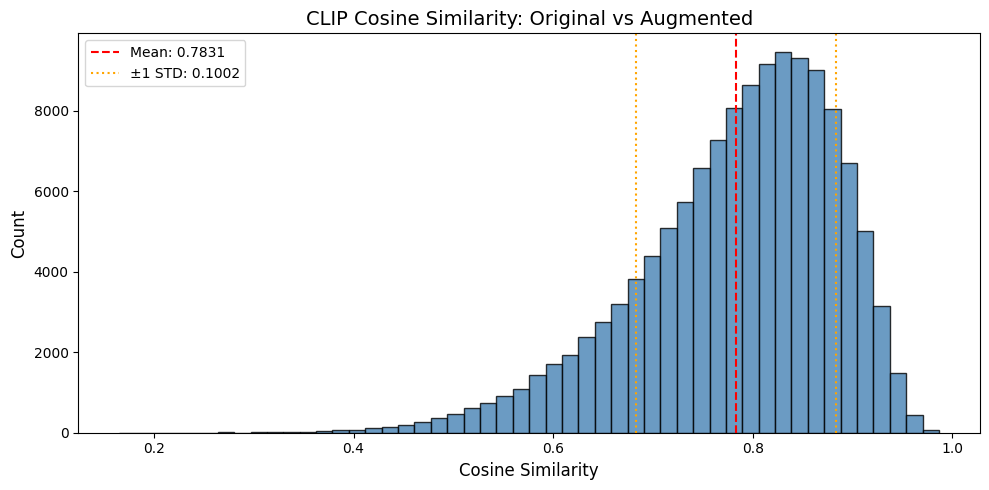

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(cosine_sims, bins=50, edgecolor='black', color='steelblue', alpha=0.8)

plt.axvline(cosine_sims.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {cosine_sims.mean():.4f}')
plt.axvline(cosine_sims.mean() - cosine_sims.std(), color='orange', linestyle=':', linewidth=1.5, label=f'±1 STD: {cosine_sims.std():.4f}')
plt.axvline(cosine_sims.mean() + cosine_sims.std(), color='orange', linestyle=':', linewidth=1.5)

plt.xlabel('Cosine Similarity', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('CLIP Cosine Similarity: Original vs Augmented', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('cosine_sim_histogram.png', dpi=150)
plt.show()

In [6]:
#Per-weather breakdown

print(f"\nPer-weather cosine similarity:")
for weather in ["sunny", "fog", "rain", "snow"]:
    mask = weather_labels == weather
    sims = cosine_sims[mask]
    print(f"{weather:<8} n={mask.sum():>6}"
          f"   mean={sims.mean():.4f}"
          f"   std={sims.std():.4f}"
          f"   min={sims.min():.4f}")


Per-weather cosine similarity:
sunny    n= 32463   mean=0.7978   std=0.0969   min=0.2633
fog      n= 32464   mean=0.7874   std=0.1013   min=0.1654
rain     n= 32464   mean=0.7833   std=0.1005   min=0.2440
snow     n= 32464   mean=0.7638   std=0.0992   min=0.2177


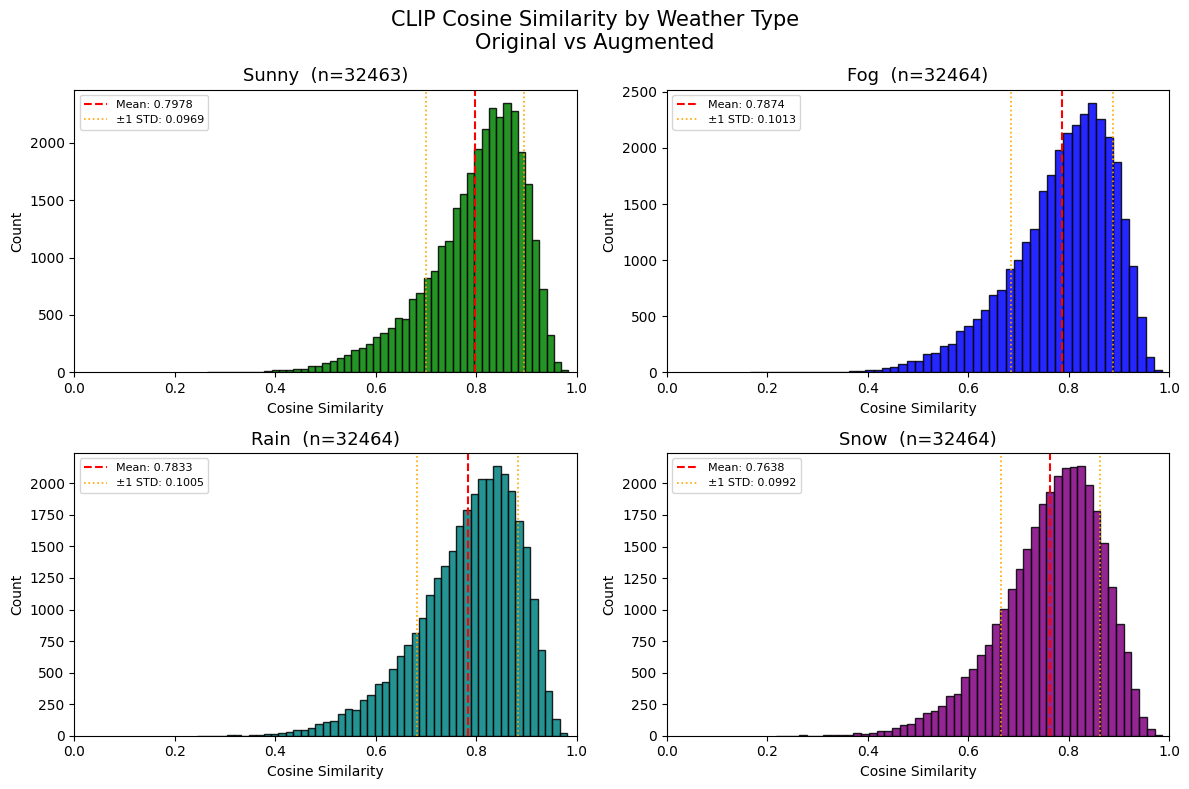

: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

weather_types = ["sunny", "fog", "rain", "snow"]
colors = ["green", "blue", "teal", "purple"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=False)
axes = axes.flatten()

for ax, weather, color in zip(axes, weather_types, colors):
    mask = weather_labels == weather
    sims = cosine_sims[mask]

    ax.hist(sims, bins=50, color=color, edgecolor='black', alpha=0.85)
    ax.axvline(sims.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {sims.mean():.4f}')
    ax.axvline(sims.mean() - sims.std(), color='orange', linestyle=':', linewidth=1.2, label=f'±1 STD: {sims.std():.4f}')
    ax.axvline(sims.mean() + sims.std(), color='orange', linestyle=':', linewidth=1.2)

    ax.set_title(f'{weather.capitalize()}  (n={mask.sum()})', fontsize=13)
    ax.set_xlabel('Cosine Similarity', fontsize=10)
    ax.set_xlim(0,1)
    ax.set_ylabel('Count', fontsize=10)
    ax.legend(fontsize=8)

fig.suptitle('CLIP Cosine Similarity by Weather Type\nOriginal vs Augmented', fontsize=15)
plt.tight_layout()
plt.savefig('cosine_sim_per_weather.png', dpi=150)
plt.show()

In [8]:
#Per-class breakdown

print(f"\nPer-class cosine similarity (sorted by mean):")
class_stats = []
for class_id in np.unique(class_ids):
    mask = class_ids == class_id
    sims = cosine_sims[mask]
    class_stats.append((class_id, mask.sum(), sims.mean(), sims.std()))

class_stats.sort(key=lambda x: x[2])
max_len = max(len(class_names[cid]) for cid, _, _, _ in class_stats)
for class_id, n, mean, std in class_stats:
    name = class_names[class_id]
    print(f"  {name:<{max_len}}  n={n:>5}  mean={mean:.4f}  std={std:.4f}")


Per-class cosine similarity (sorted by mean):
  street sign            n= 1300  mean=0.6373  std=0.1901
  freight car            n= 1300  mean=0.6907  std=0.1273
  park bench             n= 1300  mean=0.6990  std=0.1103
  triumphal arch         n= 1300  mean=0.6996  std=0.1111
  bobsled                n= 1300  mean=0.7199  std=0.1093
  lakeside               n= 1300  mean=0.7263  std=0.1076
  cliff                  n= 1300  mean=0.7293  std=0.0950
  alp                    n= 1300  mean=0.7294  std=0.1032
  sandbar                n= 1300  mean=0.7338  std=0.0860
  flagpole               n= 1300  mean=0.7367  std=0.1313
  valley                 n= 1300  mean=0.7413  std=0.0830
  harvester              n= 1300  mean=0.7457  std=0.1039
  mountain bike          n= 1300  mean=0.7457  std=0.1005
  dome                   n= 1300  mean=0.7459  std=0.1259
  stone wall             n= 1300  mean=0.7480  std=0.0881
  speedboat              n= 1300  mean=0.7483  std=0.0974
  promontory             

In [9]:
#Per-class per-weather breakdown

print(f"\nPer-class per-weather mean cosine similarity:")
for weather in ["sunny", "fog", "rain", "snow"]:
    w_mask = weather_labels == weather
    print(f"\n  {weather}:")
    for class_id in np.unique(class_ids):
        mask = w_mask & (class_ids == class_id)
        if mask.sum() == 0:
            continue
        sims = cosine_sims[mask]
        name = class_names[class_id]
        print(f"class {name:<4} n={mask.sum():>4}  mean={sims.mean():.4f}")



Per-class per-weather mean cosine similarity:

  sunny:
class ostrich n= 325  mean=0.7944
class bald eagle n= 325  mean=0.8669
class vulture n= 325  mean=0.8055
class great grey owl n= 325  mean=0.8334
class Komodo dragon n= 325  mean=0.8254
class African crocodile n= 325  mean=0.8345
class American alligator n= 325  mean=0.8381
class diamondback n= 325  mean=0.7984
class scorpion n= 325  mean=0.8131
class tarantula n= 325  mean=0.8136
class flamingo n= 325  mean=0.8708
class king penguin n= 325  mean=0.8298
class albatross n= 325  mean=0.7721
class sea lion n= 325  mean=0.7646
class timber wolf n= 325  mean=0.8357
class coyote n= 325  mean=0.7906
class African hunting dog n= 325  mean=0.7935
class red fox n= 325  mean=0.8247
class Arctic fox n= 325  mean=0.8022
class snow leopard n= 325  mean=0.7987
class lion n= 325  mean=0.8393
class tiger n= 325  mean=0.8450
class cheetah n= 325  mean=0.8140
class brown bear n= 325  mean=0.8201
class dragonfly n= 325  mean=0.7643
class monarch n= 

In [10]:
#Outlier flagging
threshold = cosine_sims.mean() - 2 * cosine_sims.std()
bad_idx = np.where(cosine_sims < threshold)[0]

print(f"\nOutliers (similarity < {threshold:.4f}): {len(bad_idx)} images")
print(f"  Weather distribution of outliers:")
for weather in ["sunny", "fog", "rain", "snow"]:
    n = (weather_labels[bad_idx] == weather).sum()
    print(f"    {weather:<8}: {n}")
print(f"  Class distribution of outliers (top 10):")
unique, counts = np.unique(class_ids[bad_idx], return_counts=True)
for class_id, count in sorted(zip(unique, counts), key=lambda x: -x[1])[:10]:
    name = class_names[class_id]
    print(f" class {name}: {count}")


Outliers (similarity < 0.5826): 5712 images
  Weather distribution of outliers:
    sunny   : 1166
    fog     : 1411
    rain    : 1443
    snow    : 1692
  Class distribution of outliers (top 10):
 class street sign: 648
 class freight car: 304
 class triumphal arch: 203
 class park bench: 194
 class dome: 178
 class flagpole: 171
 class lakeside: 162
 class bobsled: 154
 class alp: 121
 class water tower: 110


In [11]:
weather_dataset = WeatherImageNetSubset(
    root="data/imnet_subset_weather_aug",
    split="train",
    transform=None  # no need for preprocess, just need the mappings
)

clients = init_clients(weather_dataset,20,batch_size=64,dl_kwargs=None,transform=None)

client_idx_list = []
for client in clients:
    client_idx_list.append(client.subset)
    
for idxs in client_idx_list:
    print(len(idxs))

6493
6493
6493
6492
6492
6493
6493
6493
6493
6492
6493
6493
6493
6493
6492
6493
6493
6493
6493
6492


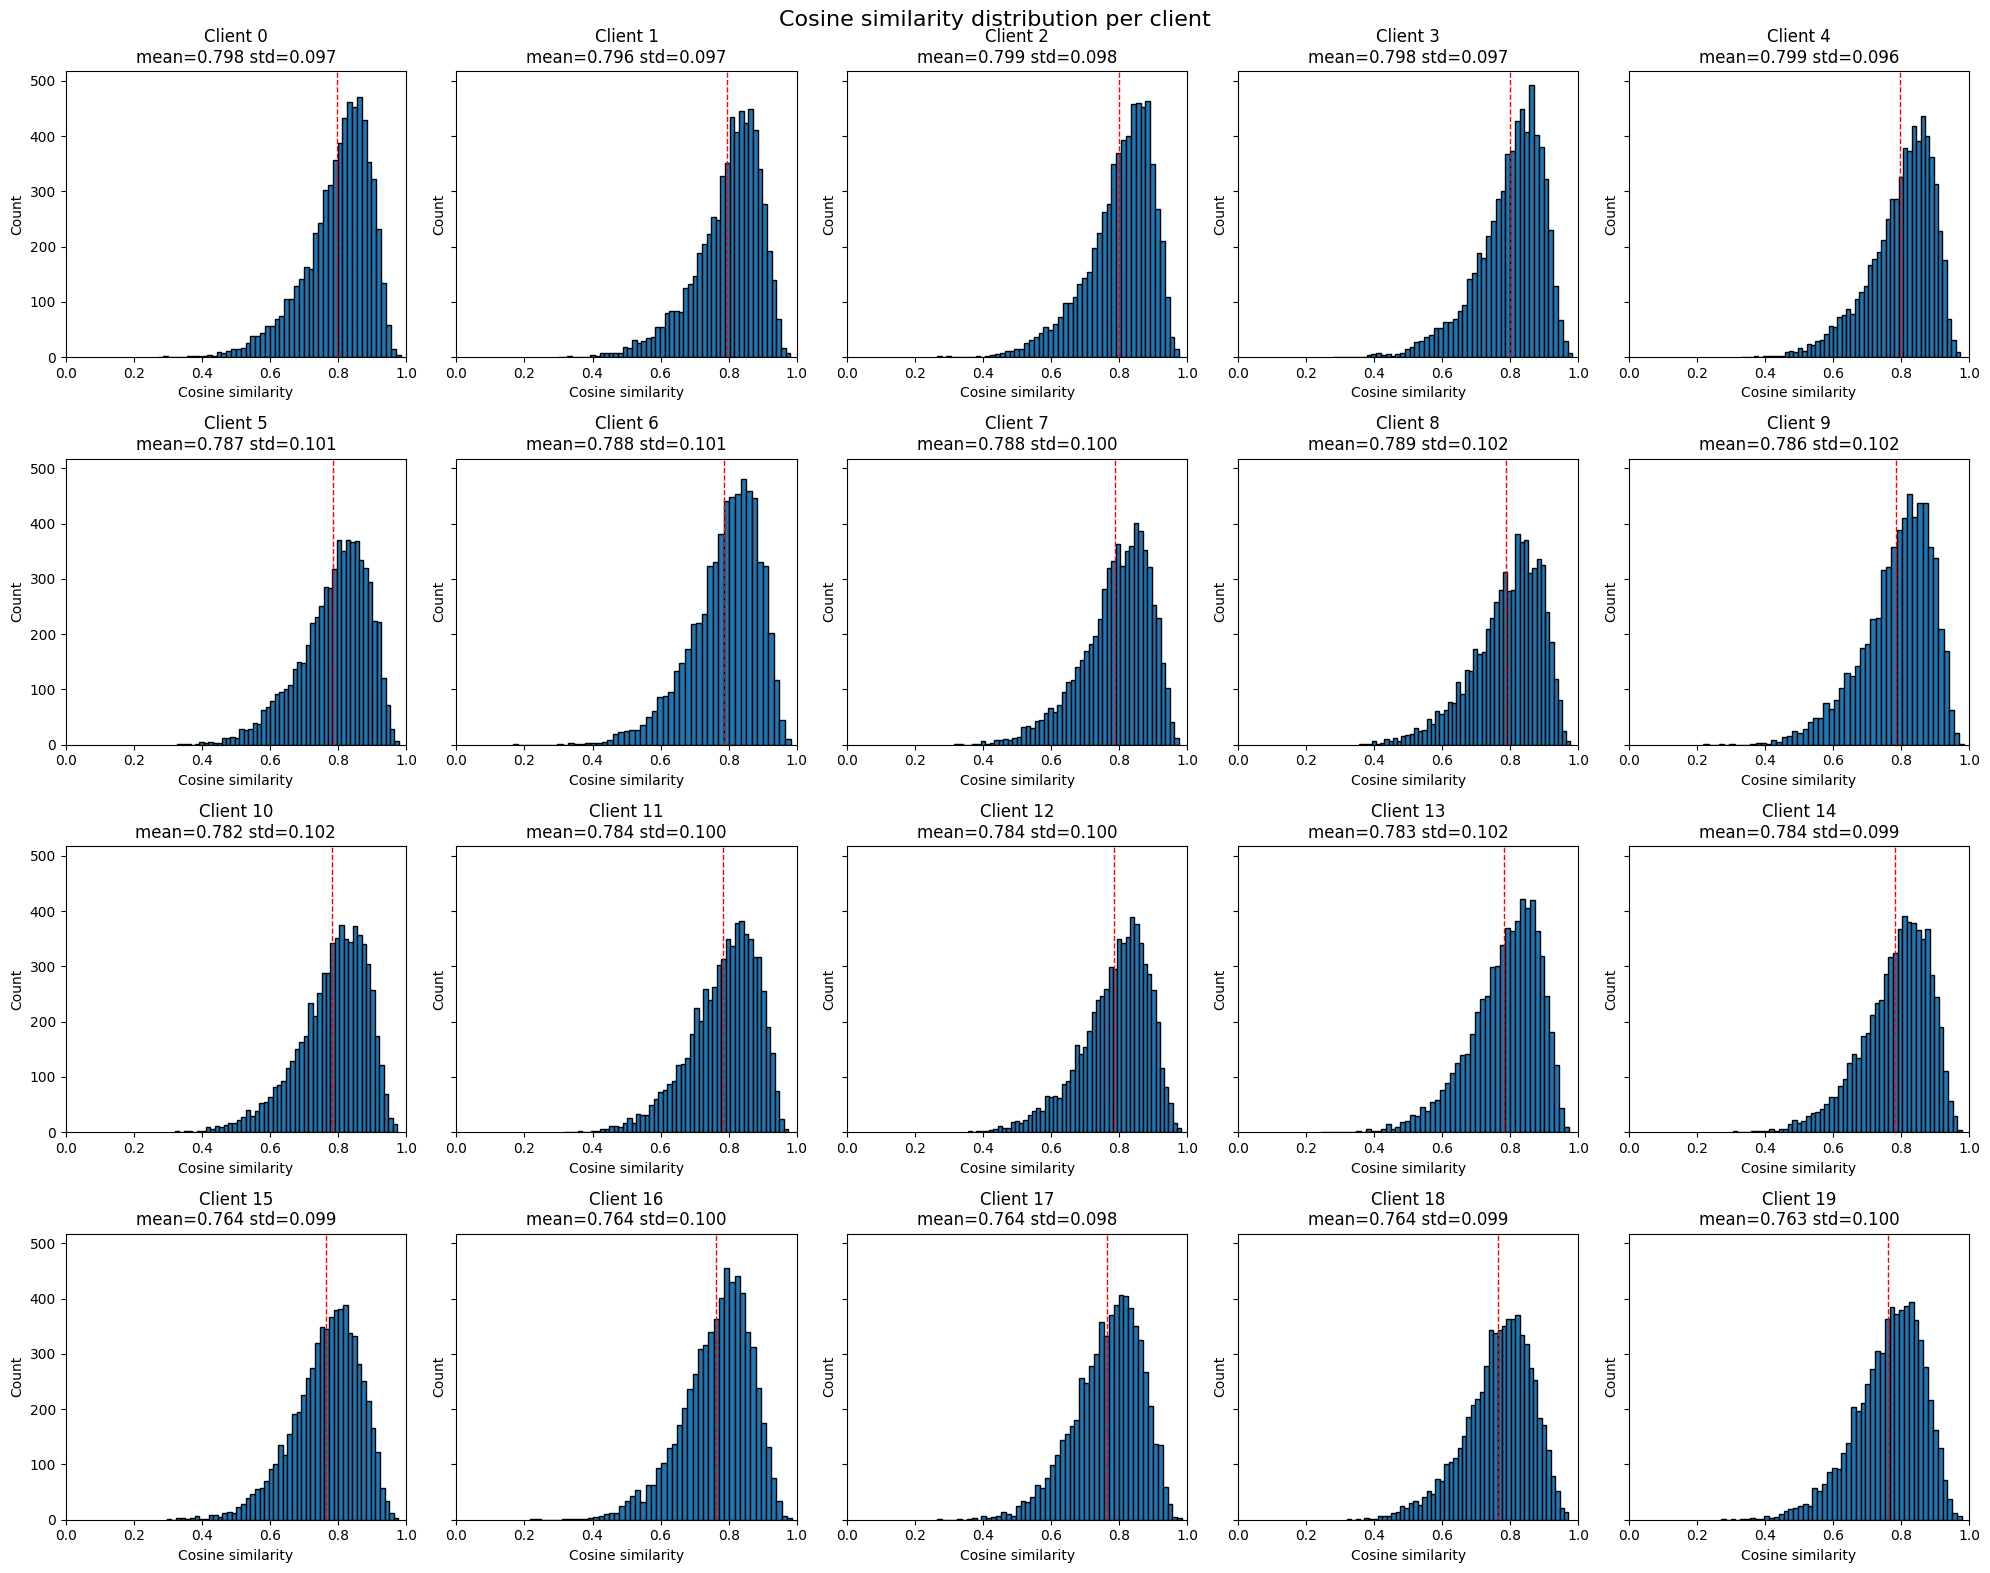

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 5, figsize=(20, 16), sharey=True)
axes = axes.flatten()

for i, idxs in enumerate(client_idx_list):
    client_sims = cosine_sims[idxs]
    
    axes[i].hist(client_sims, bins=50, edgecolor='black')
    axes[i].set_title(f"Client {i}\n"
                      f"mean={client_sims.mean():.3f} "
                      f"std={client_sims.std():.3f}")
    axes[i].set_xlabel("Cosine similarity")
    axes[i].set_xlim(0, 1)
    axes[i].set_ylabel("Count")
    axes[i].axvline(client_sims.mean(), color='red', linestyle='--', linewidth=1)

plt.suptitle("Cosine similarity distribution per client", fontsize=16)
plt.tight_layout()
plt.show()

In [13]:
# get file paths from dataset
file_paths = np.array([path for path, _ in weather_dataset.imgs])

# sort by cosine similarity ascending — worst first
worst_idx = np.argsort(cosine_sims)[:50]  # top 50 worst

for idx in worst_idx:
    print(f"sim={cosine_sims[idx]:.4f}  {file_paths[idx]}")

sim=0.1654  data/imnet_subset_weather_aug\train\n06794110\n06794110_2845_fog.JPEG
sim=0.2177  data/imnet_subset_weather_aug\train\n06794110\n06794110_2979_snow.JPEG
sim=0.2194  data/imnet_subset_weather_aug\train\n06794110\n06794110_526_fog.JPEG
sim=0.2364  data/imnet_subset_weather_aug\train\n06794110\n06794110_2399_snow.JPEG
sim=0.2440  data/imnet_subset_weather_aug\train\n06794110\n06794110_404_rain.JPEG
sim=0.2633  data/imnet_subset_weather_aug\train\n03891251\n03891251_1553_sunny.JPEG
sim=0.2650  data/imnet_subset_weather_aug\train\n02814860\n02814860_3533_snow.JPEG
sim=0.2710  data/imnet_subset_weather_aug\train\n06794110\n06794110_2272_snow.JPEG
sim=0.2726  data/imnet_subset_weather_aug\train\n06794110\n06794110_368_sunny.JPEG
sim=0.2727  data/imnet_subset_weather_aug\train\n07802026\n07802026_17448_sunny.JPEG
sim=0.2764  data/imnet_subset_weather_aug\train\n06794110\n06794110_2313_fog.JPEG
sim=0.2798  data/imnet_subset_weather_aug\train\n02835271\n02835271_2490_sunny.JPEG
sim=0